In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer 
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

In [20]:
parties_list = ['CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP']

def prediction_metric_func(predicted_theses_df_mapped:pd.DataFrame,
                           labled_theses_df:pd.DataFrame,
                           parties_list:list,
                           plot:bool=False,
                           plot_title:str=''):
    

    # Get unique labels from the dataframe
    labels = pd.unique(labled_theses_df[parties_list].values.ravel()).tolist()

    target_lables_array = labled_theses_df[parties_list].values.ravel()
    predicted_lables_array = predicted_theses_df_mapped[parties_list].values.ravel()

    accuracy    = accuracy_score(target_lables_array, predicted_lables_array)
    precision   = precision_score(target_lables_array, predicted_lables_array, average="macro")
    recall      = recall_score(target_lables_array, predicted_lables_array, average="macro")
    f1          = f1_score(target_lables_array, predicted_lables_array, average="macro")

    if plot:
        # Confusion Matrix berechnen
        cm = confusion_matrix(target_lables_array,
                            predicted_lables_array,
                            labels=labels)

        # Classification Report als einfachen String holen
        report_text = classification_report(target_lables_array,
                                            predicted_lables_array,
                                            labels=labels,
                                            target_names=labels)

        # Plot erstellen
        fig, ax = plt.subplots(figsize=(6, 6))

        # Heatmap zeichnen
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")
        ax.set_title(plot_title)

        # Classification Report als Text im Plot ausgeben
        plt.gcf().text(0.07, 0.15, report_text, fontsize = 10, ha="left", va="center", family="monospace")

        plt.subplots_adjust(bottom=0.4)  # Falls der Text unten abgeschnitten wird

        plt.show()

    return [accuracy, precision, recall, f1]

Modell laden 

In [4]:
model = AutoModelForSequenceClassification.from_pretrained("manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

Wahlomat klassifizieren

In [8]:
# Wahlomat-Thesen zu Manifesto Kategorien mappen, z.B. These 1 wird zu Welfare State Expansion gemappt 
# Wahlomat-Thesen laden
df_questions = pd.read_csv("wahlomaten_thesen_positionen.csv")

# Liste für Ergebnisse
results = []

for index, row in df_questions.iterrows():
    sentence = row["These"]
    context = sentence  # Nutzen der These selbst, als Versuch, sonst wohl text aus txt datei nehmen?

    # Tokenisierung, Max len angepasst, muss im finetuning geändert werden 
    inputs = tokenizer(sentence, context, return_tensors="pt", max_length=512, padding="max_length", truncation=True)

    # Modellvorhersage
    logits = model(**inputs).logits
    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    
    # Mapping der ID zur Policy-Kategorie
    probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
    probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
    
    # Beste Kategorie auswählen, Alternativ könnten hier auch alle Wahrscheinlichkeiten zum Vergleich genommen werden
    predicted_class = model.config.id2label[logits.argmax().item()]

    results.append({"These": sentence, "Best_Policy_Category": predicted_class, "Full_Probabilities": probabilities})

# Ergebnisse als DataFrame speichern
df_results = pd.DataFrame(results)
df_results.to_csv("wahlomat_policy_predictions.csv", index=False)

print("Wahlomat-Kategorien gespeichert in 'wahlomat_policy_predictions.csv'")

Wahlomat-Kategorien gespeichert in 'wahlomat_policy_predictions.csv'


Parteien klassifizieren

In [11]:
df = pd.read_parquet("all_parties_text_combined_prep.parquet")

# Duplikate aus Thesen entfernen
df_filtered = df.dropna(subset=["These"]).drop_duplicates(subset=["Party", "These"])

all_results = []

# Klassifizierung der Thesen
for index, row in df_filtered.iterrows():
    party = row["Party"]
    thesis = row["These"]
    context = row["Text"]  
    print("Started: ", index)

    # Vorhersage
    inputs = tokenizer(thesis, context, return_tensors="pt", max_length=512, padding="max_length", truncation=True)
    logits = model(**inputs).logits
    #print("Predicted: ", index)

    # Wahrscheinlichkeit berechnen 
    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    predicted_class = model.config.id2label[logits.argmax().item()]
    print("probability: ", index)

    all_results.append({
        "Partei": party,
        "These": thesis,
        "Text": context,
        "Policy_Category": predicted_class
    })

#print("End of for loop")
# Ergebnisse speichern
df_results = pd.DataFrame(all_results)

df_results.to_csv("classified_text_results_all_parties.csv", index=False)
print("Partei-Kategorien gespeichert in 'classified_text_results_all_parties.csv'")


Started:  3
probability:  3
Started:  4
probability:  4
Started:  5
probability:  5
Started:  6
probability:  6
Started:  8
probability:  8
Started:  9
probability:  9
Started:  11
probability:  11
Started:  12
probability:  12
Started:  13
probability:  13
Started:  14
probability:  14
Started:  16
probability:  16
Started:  17
probability:  17
Started:  18
probability:  18
Started:  19
probability:  19
Started:  21
probability:  21
Started:  22
probability:  22
Started:  25
probability:  25
Started:  26
probability:  26
Started:  27
probability:  27
Started:  29
probability:  29
Started:  30
probability:  30
Started:  31
probability:  31
Started:  33
probability:  33
Started:  35
probability:  35
Started:  36
probability:  36
Started:  37
probability:  37
Started:  38
probability:  38
Started:  40
probability:  40
Started:  42
probability:  42
Started:  43
probability:  43
Started:  45
probability:  45
Started:  46
probability:  46
Started:  48
probability:  48
Started:  49
probabili

Parteien und Wahlomat vergleichen

In [ ]:
# Aus Klassifizierten Wahlomat und Partei Texten übereinstimmung analysieren
# Wahlomat-Daten
df_wahlomat = pd.read_csv("wahlomat_policy_predictions.csv")
df_wahlomat = df_wahlomat[["These", "Best_Policy_Category"]]

# Partei-Daten 
df_parties = pd.read_csv("classified_text_results_all_parties.csv")  # Enthält Positionen aller Parteien

# Mapping der Klassen auf Basis der Domainen 
def determine_position(wahlomat_category, party_categories):
    """
    Bestimmt die Haltung einer Partei basierend auf der Policy-Kategorie der Wahlomat-These.
    """
    opposite_policies = {
        "504 - Welfare State Expansion": "505 - Welfare State Limitation",
        "505 - Welfare State Limitation": "504 - Welfare State Expansion",
        "701 - Labour Groups: Positive": "702 - Labour Groups: Negative",
        "702 - Labour Groups: Negative": "701 - Labour Groups: Positive",
        "406 - Protectionism: Positive": "407 - Protectionism: Negative",
        "407 - Protectionism: Negative": "406 - Protectionism: Positive",
        "506 - Education Expansion": "507 - Education Limitation",
        "507 - Education Limitation": "506 - Education Expansion",
        "401 - Free Market Economy": "412 - Controlled Economy",
        "412 - Controlled Economy": "401 - Free Market Economy",
        "101 - Foreign Special Relationships: Positive": "102 - Foreign Special Relationships: Negative",
        "102 - Foreign Special Relationships: Negative": "101 - Foreign Special Relationships: Positive",
        "103 - Anti-Imperialism": "108 - European Community/Union: Positive",
        "104 - Military: Positive": "105 - Military: Negative",
        "105 - Military: Negative": "104 - Military: Positive",
        "106 - Peace": "104 - Military: Positive",
        "107 - Internationalism: Positive": "109 - Internationalism: Negative",
        "109 - Internationalism: Negative": "107 - Internationalism: Positive",
        "108 - European Community/Union: Positive": "110 - European Community/Union: Negative",
        "110 - European Community/Union: Negative": "108 - European Community/Union: Positive",
        "201 - Freedom and Human Rights": "605 - Law and Order: Positive",
        "202 - Democracy": "305 - Political Authority",
        "203 - Constitutionalism: Positive": "204 - Constitutionalism: Negative",
        "204 - Constitutionalism: Negative": "203 - Constitutionalism: Positive",
        "301 - Federalism": "302 - Centralisation",
        "302 - Centralisation": "301 - Federalism",
        "303 - Governmental and Administrative Efficiency": "304 - Political Corruption",
        "304 - Political Corruption": "303 - Governmental and Administrative Efficiency",
        "305 - Political Authority": "202 - Democracy",
        "402 - Incentives: Positive": "409 - Keynesian Demand Management",
        "409 - Keynesian Demand Management": "402 - Incentives: Positive",
        "403 - Market Regulation": "404 - Economic Planning",
        "404 - Economic Planning": "403 - Market Regulation",
        "405 - Corporatism/ Mixed Economy": "401 - Free Market Economy",
        "410 - Economic Growth: Positive": "416 - Anti-Growth Economy: Positive",
        "416 - Anti-Growth Economy: Positive": "410 - Economic Growth: Positive",
        "501 - Environmental Protection: Positive": "502 - Culture: Positive",
        "601 - National Way of Life: Positive": "602 - National Way of Life: Negative",
        "602 - National Way of Life: Negative": "601 - National Way of Life: Positive",
        "603 - Traditional Morality: Positive": "604 - Traditional Morality: Negative",
        "604 - Traditional Morality: Negative": "603 - Traditional Morality: Positive",
        "605 - Law and Order: Positive": "201 - Freedom and Human Rights",
        "606 - Civic Mindedness: Positive": "604 - Traditional Morality: Negative",
        "607 - Multiculturalism: Positive": "608 - Multiculturalism: Negative",
        "608 - Multiculturalism: Negative": "607 - Multiculturalism: Positive",
        "704 - Middle Class and Professional Groups": "705 - Underprivileged Minority Groups",
        "705 - Underprivileged Minority Groups": "704 - Middle Class and Professional Groups"
    }


    if wahlomat_category in party_categories:
        return "stimme zu"
    elif wahlomat_category in opposite_policies and opposite_policies[wahlomat_category] in party_categories:
        return "stimme nicht zu"
    else:
        return "neutral"

party_names = df_parties["Partei"].unique()  # Alle Parteien im Datensatz

# Neuen DataFrame vorbereiten
df_wahlomat_results = df_wahlomat.copy()

for party in party_names:
    # Kategorien für die aktuelle Partei
    party_policy_set = set(df_parties[df_parties["Partei"] == party]["Policy_Category"].unique())

    # Partei-Position für jede Wahlomat-These
    df_wahlomat_results[f"{party}_Model_Prediction"] = df_wahlomat_results["Best_Policy_Category"].apply(
        lambda cat: determine_position(cat, party_policy_set)
    )


df_wahlomat_results.to_csv("all_parties_wahlomat_policy_matching.csv", index=False)

In [60]:
# Aus Klassifizierten Wahlomat und Partei Texten übereinstimmung analysieren
# Wahlomat-Daten
df_wahlomat = pd.read_csv("wahlomat_policy_predictions.csv")
df_wahlomat = df_wahlomat[["These", "Best_Policy_Category"]]

# Partei-Daten 
df_parties = pd.read_csv("classified_text_results_all_parties.csv")  # Enthält Positionen aller Parteien

df_wahlomat["Best_Policy_Category"] = df_wahlomat["Best_Policy_Category"].astype(str).str[:3]
df_parties["Policy_Category"] = df_parties["Policy_Category"].astype(str).str[:3]

# Adjazenzmatrix laden
adj_matrix = pd.read_parquet("adjazenzmatrix.parquet")  # Stelle sicher, dass die Matrix als CSV gespeichert ist

def determine_position_adj(wahlomat_category, party_categories, adj_matrix):
    """
    Bestimmt die Haltung einer Partei basierend auf der Adjazenzmatrix.
    """
    for party_category in party_categories:
        if wahlomat_category not in adj_matrix.index or party_category not in adj_matrix.columns:
            continue  # Falls eine Kategorie nicht in der Matrix ist, ignorieren

        relationship = adj_matrix.at[wahlomat_category, party_category]

        if relationship == 1:
            return "stimme zu"
        elif relationship == -1:
            return "stimme nicht zu"

    return "neutral"

In [61]:
df_parties

,Partei,These,Text,Policy_Category
0,spd,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un...",402
1,spd,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...,402
2,spd,Wir wollen Bürokratie abbauen und Verfahren be...,Damit unsere Wirtschaft wieder schnell in Schw...,303
3,spd,"Wir wollen Innovationen ermöglichen, die Deuts...",Der viel beschworene Erfndergeist in Deutschla...,411
4,spd,"Wir wollen eine stabile, breit aufgestellte un...","Unsere Unternehmen müssen sicher sein, dass si...",408
...,...,...,...,...
557,linke,Niemand flieht freiwillig,Das Chaos an den europäischen Grenzen ist das ...,201
558,linke,Wir sind eine Einwanderungsgesellschaft – und ...,Die großen Herausforderungen von mehr Personal...,607
559,linke,Kultur – vielfältig und für alle zugänglich,Der Zugang zu Kultur soll nicht vom Geldbeutel...,503
560,linke,Sport ist kein Luxus,Sport ist für alle da. Dafür müssen die Zugang...,503


In [62]:
party_names = df_parties["Partei"].unique()  # Alle Parteien im Datensatz

# Neuen DataFrame vorbereiten
df_wahlomat_results = df_wahlomat.copy()

for party in party_names:
    # Kategorien für die aktuelle Partei
    party_policy_set = set(df_parties[df_parties["Partei"] == party]["Policy_Category"].unique())

    # Partei-Position für jede Wahlomat-These
    df_wahlomat_results[f"{party}_Model_Prediction"] = df_wahlomat_results["Best_Policy_Category"].apply(
        lambda cat: determine_position_adj(cat, party_policy_set, adj_matrix)
    )


df_wahlomat_results.to_csv("all_parties_wahlomat_policy_matching.csv", index=False)

Ergebnisse visualisieren 

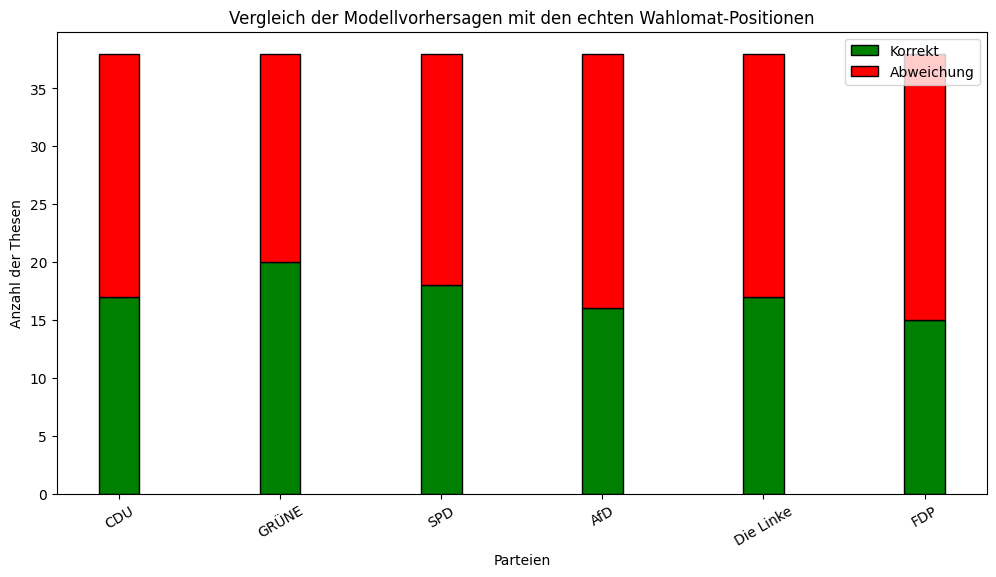

In [64]:
# Visualisieren der Ergebnisse

#  Wahlomat-Daten (Original // True Werte)
df_wahlomat_true = pd.read_csv("wahlomaten_thesen_positionen.csv")  # Enthält tatsächliche Wahlomat-Antworten
df_wahlomat_true = df_wahlomat_true.rename(columns={"CDU / CSU": "CDU"})  
df_wahlomat_true = df_wahlomat_true[["These", "CDU", "GRÜNE", "SPD", "AfD", "Die Linke", "FDP"]]  # Nur relevante Spalten behalten

# Predictions für Parteien --> These entspricht hier der Wahlomat These
df_wahlomat_pred = pd.read_csv("all_parties_wahlomat_policy_matching.csv")  # Modell-Vorhersagen der Parteien


df_comparison = df_wahlomat_true.merge(df_wahlomat_pred, on="These", how="left")

# Übereinstimmungen prüfen 
parties = ["CDU", "GRÜNE", "SPD", "AfD", "Die Linke", "FDP"]

party_model_mapping = {
    "CDU": "cdu_Model_Prediction",
    "GRÜNE": "gruene_Model_Prediction",
    "SPD": "spd_Model_Prediction",
    "AfD": "afd_Model_Prediction",
    "Die Linke": "linke_Model_Prediction",
    "FDP": "fdp_Model_Prediction"
}

metrics = []

# Übereinstimmungen prüfen 
results = {}
for party, model_col in party_model_mapping.items():
    if model_col in df_comparison.columns:  
        df_comparison[f"Abweichung_{party}"] = df_comparison.apply(
            lambda row: "Korrekt" if row[party] == row[model_col] else "Abweichung", axis=1
        )
        results[party] = df_comparison[f"Abweichung_{party}"].value_counts()

        # Metriken vorbereiten & berechnen
        y_true = df_comparison[party] 
        y_pred = df_comparison[model_col]  

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="macro")
        recall = recall_score(y_true, y_pred, average="macro")
        f1 = f1_score(y_true, y_pred, average="macro")

        metrics.append({
            "Partei": party,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

df_metrics = pd.DataFrame(metrics)

# Plot 
plt.figure(figsize=(12, 6))
bar_width = 0.25
index = range(len(parties))

correct_counts = [results[party].get("Korrekt", 0) for party in parties]
incorrect_counts = [results[party].get("Abweichung", 0) for party in parties]

plt.bar(index, correct_counts, bar_width, label="Korrekt", color="green", edgecolor="black")
plt.bar(index, incorrect_counts, bar_width, bottom=correct_counts, label="Abweichung", color="red", edgecolor="black")

plt.title("Vergleich der Modellvorhersagen mit den echten Wahlomat-Positionen")
plt.xlabel("Parteien")
plt.ylabel("Anzahl der Thesen")
plt.xticks(index, parties, rotation=30)
plt.legend(loc="upper right")
plt.show()

# Ergebnisse speichern
df_comparison.to_csv("all_parties_wahlomat_vergleich_plot.csv", index=False)


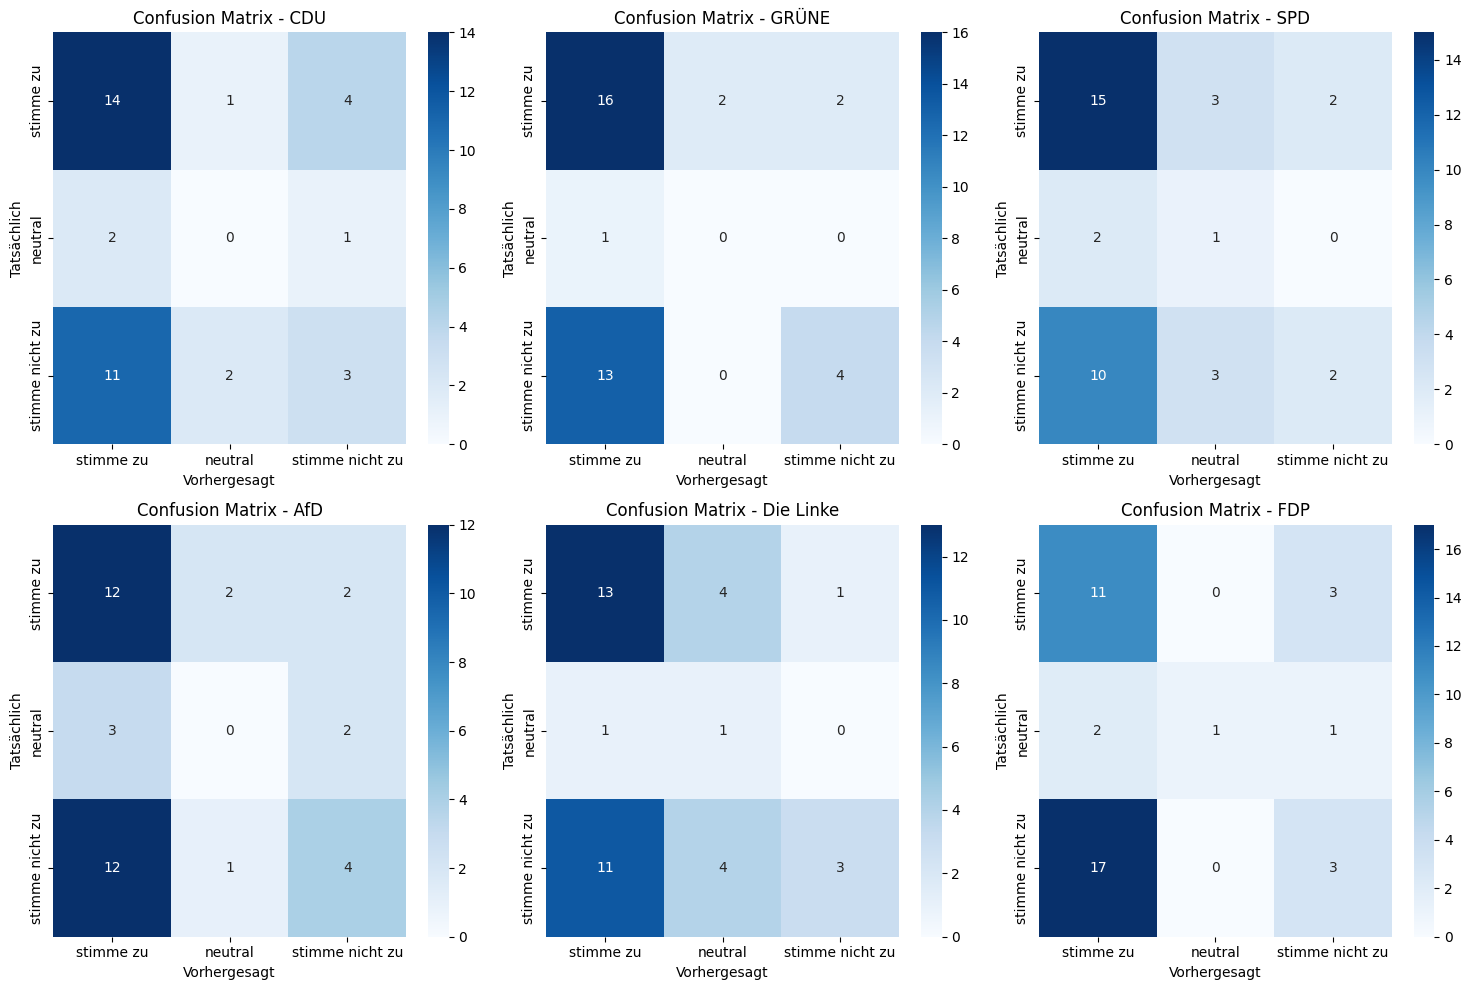

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 Reihen, 3 Spalten für Parteien

for i, (party, model_col) in enumerate(party_model_mapping.items()):
    if model_col in df_comparison.columns:  # Sicherstellen, dass die Spalte existiert
        # **Erstellen der Confusion Matrix**
        cm = confusion_matrix(df_comparison[party], df_comparison[model_col], labels=["stimme zu", "neutral", "stimme nicht zu"])
        
        # **Visualisierung der Confusion Matrix mit Seaborn**
        ax = axes[i // 3, i % 3]  # Positionierung im Grid
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["stimme zu", "neutral", "stimme nicht zu"], 
                    yticklabels=["stimme zu", "neutral", "stimme nicht zu"], ax=ax)
        
        ax.set_title(f"Confusion Matrix - {party}")
        ax.set_xlabel("Vorhergesagt")
        ax.set_ylabel("Tatsächlich")

plt.tight_layout()

In [ ]:
model_name = 'manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1'

<Figure size 600x600 with 0 Axes>

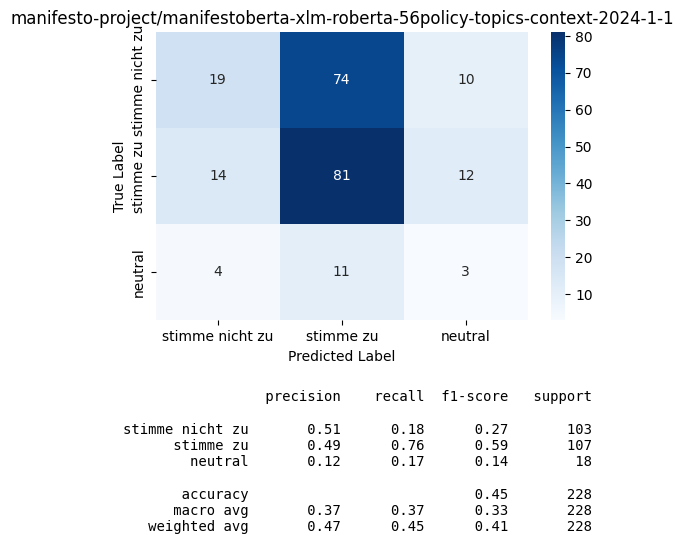

In [ ]:
# Alle True Labels & Predictions für alle Parteien sammeln
true_labels = []
predicted_labels = []

for party, model_col in party_model_mapping.items():
    if model_col in df_comparison.columns:  
        true_labels.extend(df_comparison[party].tolist()) 
        predicted_labels.extend(df_comparison[model_col].tolist())

# Labels für die Confusion Matrix definieren
labels = ["stimme nicht zu", "stimme zu", "neutral"]

# Confusion Matrix berechnen
cm = confusion_matrix(true_labels, predicted_labels, labels=labels)

# Classification Report erstellen 
report_text = classification_report(true_labels, predicted_labels, labels=labels, target_names=labels)

# Confusion Matrix plotten
plt.figure(figsize=(6, 6))
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.title(f"{model_name}")

plt.gcf().text(0.07, 0.15, report_text, fontsize = 10, ha="left", va="center", family="monospace")
plt.subplots_adjust(bottom=0.4)

plt.show()


In [80]:
model_prediction_scores = pd.DataFrame(
    [["manifestoberta-xlm-roberta-56policy-topics-context", "These", "These", "class prefitted", accuracy, precision, recall, f1]],
    columns=['model', 'lable_text_column', 'party_text_column', 'Manifesto_sorted', 'accuracy', 'precision', 'recall', 'f1']
)

# Ergebnisse als pkl speichern
with open("model_prediction_score.pkl", "wb") as f:
    pickle.dump(model_prediction_scores, f)